In [1]:
pip install tensorflow pandas matplotlib pillow scikit-learn notebook jupyter

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
dataset_path = r"C:\Users\sarov\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage"

In [4]:
classes = os.listdir(dataset_path)

print("Number of Classes:", len(classes))
print("\nClass Names:")

for cls in classes:
    print(cls)

Number of Classes: 16

Class Names:
Pepper__bell___Bacterial_spot
Pepper__bell___healthy
PlantVillage
Potato___Early_blight
Potato___healthy
Potato___Late_blight
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_healthy
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_mosaic_virus
Tomato__Tomato_YellowLeaf__Curl_Virus


In [5]:
class_df = pd.DataFrame(classes, columns=["Disease Class"])

class_df

,Disease Class
0,Pepper__bell___Bacterial_spot
1,Pepper__bell___healthy
2,PlantVillage
3,Potato___Early_blight
4,Potato___healthy
5,Potato___Late_blight
6,Tomato_Bacterial_spot
7,Tomato_Early_blight
8,Tomato_healthy
9,Tomato_Late_blight


In [6]:
class_df.to_csv("Outputs/class_names.csv", index=False)

print("Class names saved successfully.")

Class names saved successfully.


In [7]:
import os

image_count = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):
        image_count[cls] = len(os.listdir(class_path))

image_count

{'Pepper__bell___Bacterial_spot': 997,
 'Pepper__bell___healthy': 1478,
 'PlantVillage': 15,
 'Potato___Early_blight': 1000,
 'Potato___healthy': 152,
 'Potato___Late_blight': 1000,
 'Tomato_Bacterial_spot': 2127,
 'Tomato_Early_blight': 1000,
 'Tomato_healthy': 1591,
 'Tomato_Late_blight': 1909,
 'Tomato_Leaf_Mold': 952,
 'Tomato_Septoria_leaf_spot': 1771,
 'Tomato_Spider_mites_Two_spotted_spider_mite': 1676,
 'Tomato__Target_Spot': 1404,
 'Tomato__Tomato_mosaic_virus': 373,
 'Tomato__Tomato_YellowLeaf__Curl_Virus': 3209}

In [8]:
count_df = pd.DataFrame(
    image_count.items(),
    columns=["Disease Class", "Number of Images"]
)

count_df

,Disease Class,Number of Images
0,Pepper__bell___Bacterial_spot,997
1,Pepper__bell___healthy,1478
2,PlantVillage,15
3,Potato___Early_blight,1000
4,Potato___healthy,152
5,Potato___Late_blight,1000
6,Tomato_Bacterial_spot,2127
7,Tomato_Early_blight,1000
8,Tomato_healthy,1591
9,Tomato_Late_blight,1909


In [9]:
count_df.to_csv("Outputs/image_count.csv", index=False)

print("Image count table saved successfully.")

Image count table saved successfully.


In [10]:
total_images = count_df["Number of Images"].sum()

print("Total Classes :", len(count_df))
print("Total Images  :", total_images)

Total Classes : 16
Total Images  : 20654


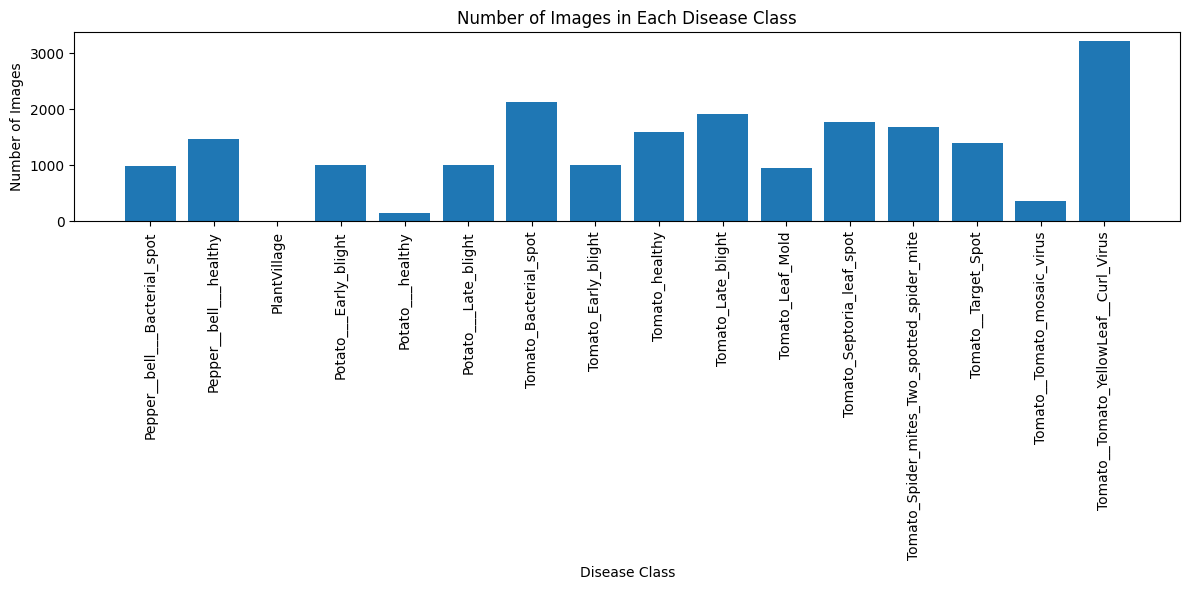

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(count_df["Disease Class"], count_df["Number of Images"])

plt.title("Number of Images in Each Disease Class")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [12]:
largest = count_df.loc[count_df["Number of Images"].idxmax()]
smallest = count_df.loc[count_df["Number of Images"].idxmin()]

print("Largest Class")
print(largest)

print("\nSmallest Class")
print(smallest)

Largest Class
Disease Class       Tomato__Tomato_YellowLeaf__Curl_Virus
Number of Images                                     3209
Name: 15, dtype: object

Smallest Class
Disease Class       PlantVillage
Number of Images              15
Name: 2, dtype: object


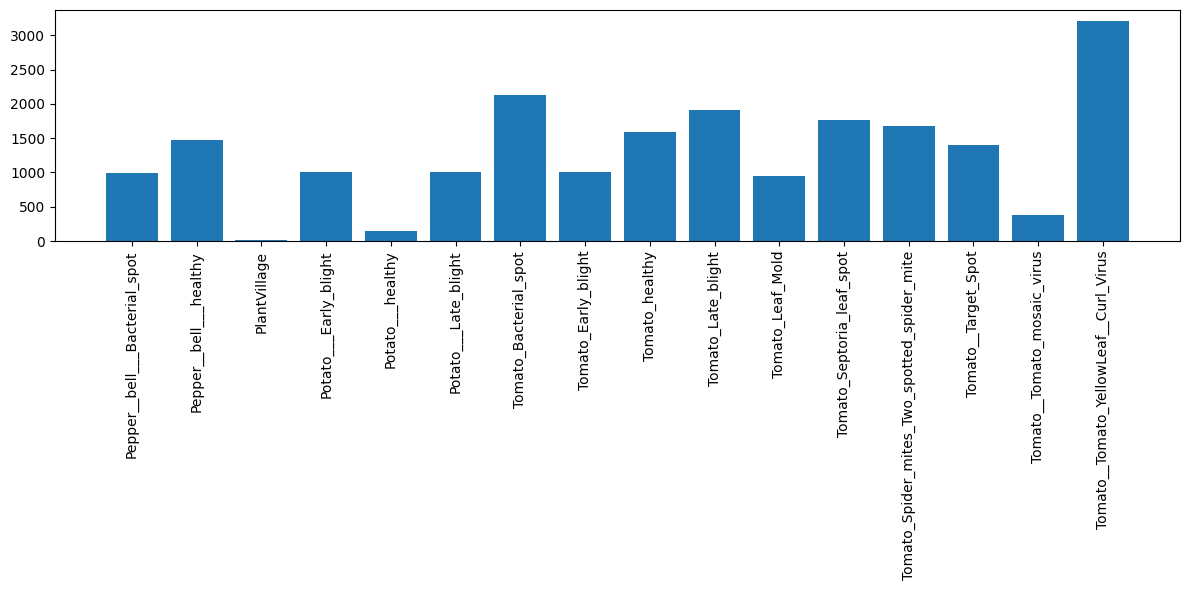

In [13]:
plt.figure(figsize=(12,6))

plt.bar(count_df["Disease Class"], count_df["Number of Images"])

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("Outputs/class_distribution.png")

plt.show()

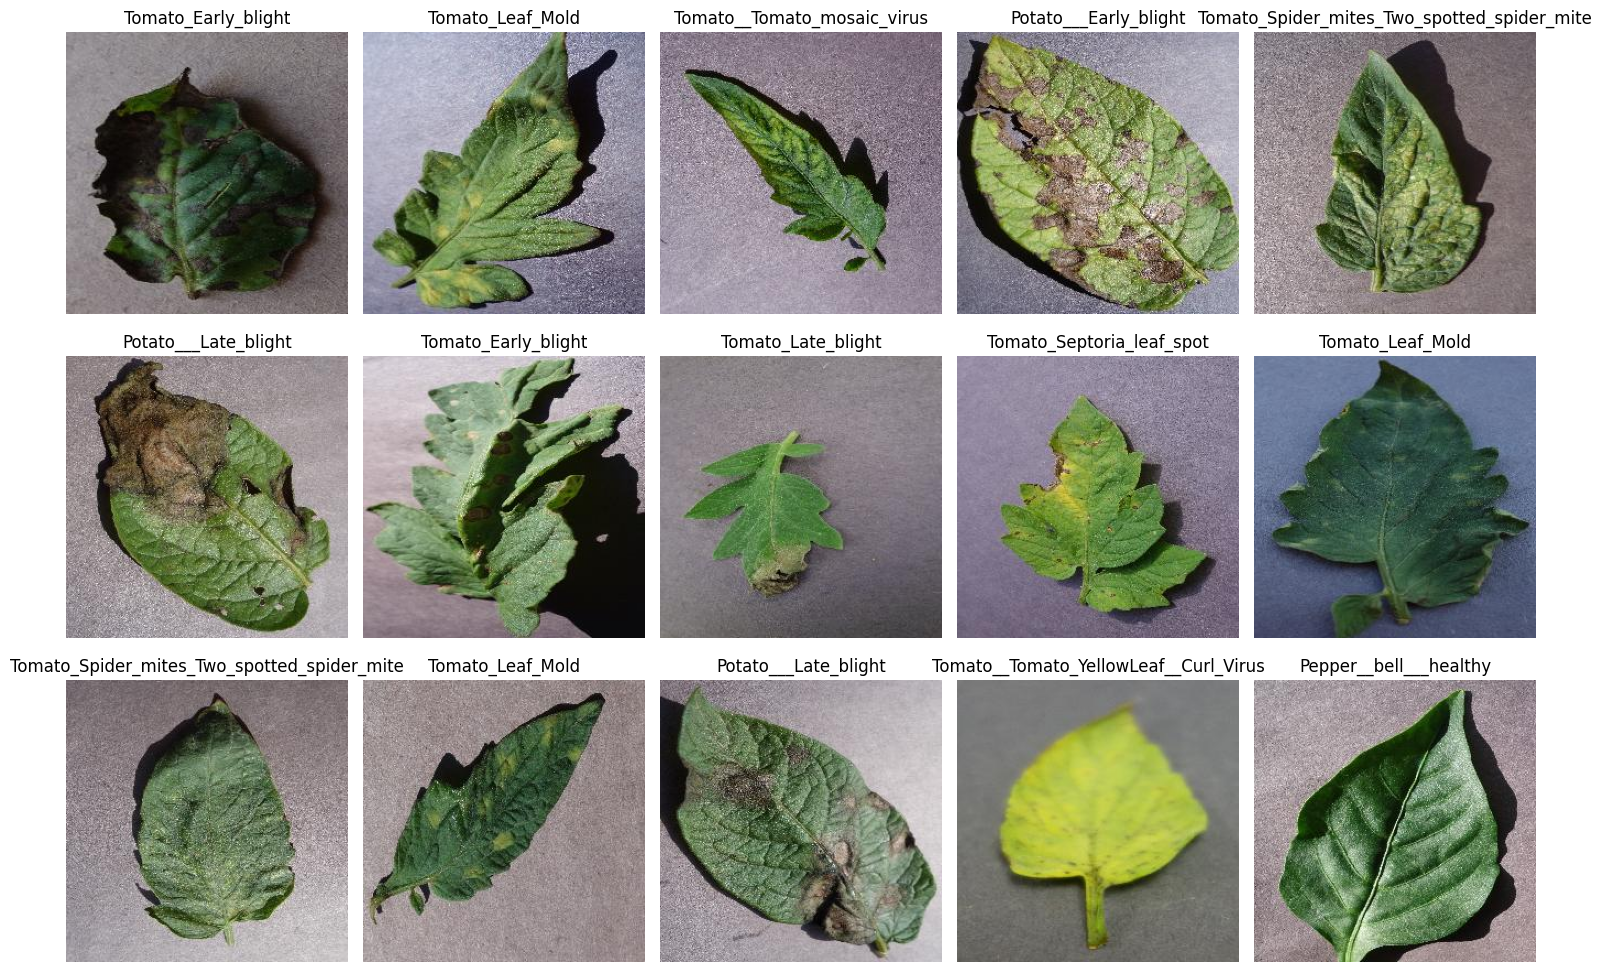

In [15]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = r"C:\Users\sarov\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage\PlantVillage"
plt.figure(figsize=(15,10))

classes = os.listdir(dataset_path)

for i in range(15):

    class_name = random.choice(classes)
    class_path = os.path.join(dataset_path, class_name)

    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path)

    plt.subplot(3,5,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
from PIL import Image
import os
import pandas as pd

sizes = []

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        try:
            img = Image.open(img_path)
            sizes.append(img.size)

        except Exception:
            print("Skipped:", img_path)

size_df = pd.DataFrame(sizes, columns=["Width", "Height"])

size_df.describe()

Skipped: C:\Users\sarov\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage\PlantVillage\Tomato__Tomato_YellowLeaf__Curl_Virus\svn-r6Yb5c


,Width,Height
count,20638.0,20638.0
mean,256.0,256.0
std,0.0,0.0
min,256.0,256.0
25%,256.0,256.0
50%,256.0,256.0
75%,256.0,256.0
max,256.0,256.0


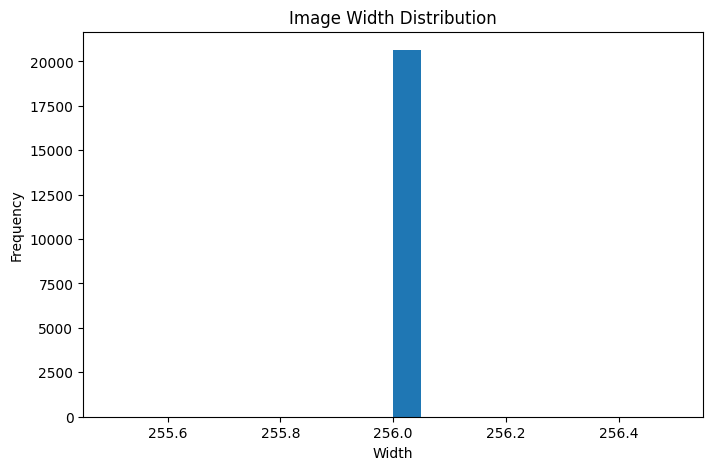

In [17]:
plt.figure(figsize=(8,5))

plt.hist(size_df["Width"], bins=20)

plt.title("Image Width Distribution")

plt.xlabel("Width")

plt.ylabel("Frequency")

plt.show()

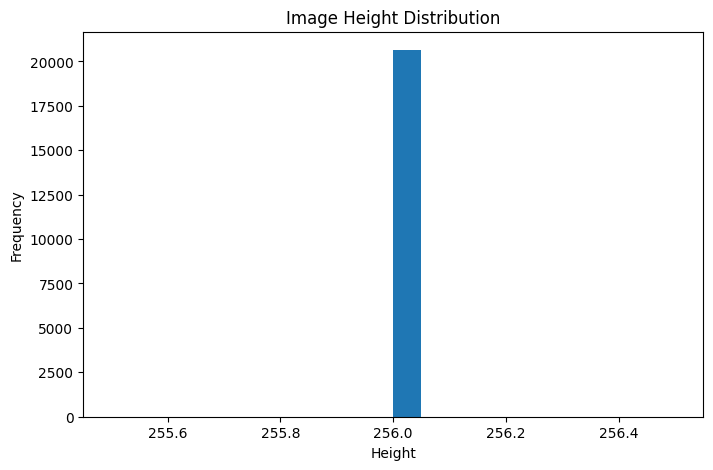

In [18]:
plt.figure(figsize=(8,5))

plt.hist(size_df["Height"], bins=20)

plt.title("Image Height Distribution")

plt.xlabel("Height")

plt.ylabel("Frequency")

plt.show()